# Laplacian Eigenmaps and Logistic Regression

*August 4 2026*  
*Training Workshop: Introduction to Deep Graph Learning*  
*Ingo Scholtes, CAIDAS, Julius-Maximilians-Universität Würzburg (JMU), Germany*  

In a first practice notebook addressing machine learning in complex networks, we combine Laplacian eigenmaps to obtain a Euclidean representation of a graph with logistic regression to implement supervised node classification and supervised link prediction.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy as sp
import seaborn as sns
from sklearn import metrics
from sklearn.datasets import make_circles
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

import pathpyG as pp

plt.style.use('default')
sns.set_style("whitegrid")

## Supervised Node Classification

As a simple example for (binary) node classification, we use the Karate club network which contains ground truth binary class labels for nodes. We can print the network to get a description of the underlying data set.

In [ ]:
n = pp.io.read_netzschleuder_graph(name='karate', network='77')
print(n)

In the description of the data, we see that there is an integer vertex property `groups` that contains the ground truth classes that we can use to train and validate our logistic regression classifier. Let's plot the network, coloring nodes according to the class labels.

In [ ]:
colors = {}
colors[0] = 'orange'
colors[1] = 'CornflowerBlue'

# use zero-based group indices to facilitate binary classification
node_colors = {v: colors[n['node_groups', v].item() - 1] for v in n.nodes}
node_labels = {v: str(v) for v in n.nodes}

plot_style = {}
plot_style['edge_opacity'] = 0.5
plot_style['edge_color'] = 'gray'
plot_style['node_opacity'] = 1.0
plot_style['node_size'] = 15
plot_style['node_color'] = node_colors
plot_style['node_label'] = node_labels

fr_karate = pp.layout(n, layout='Fruchterman-Reingold', seed=1, iterations=2500)

pp.plot(n, **plot_style, layout=fr_karate, backend='matplotlib', width='400px', height='600px');

We store the nodes as well as the group information in a `pandas` data frame. We can easily split this into a training and test set using the `sklearn` function `train_test_split`:

In [ ]:
nodes = [(v, n['node_groups', v].item() - 1) for v in n.nodes]
data = pd.DataFrame(nodes, columns=['v', 'group'])

train, test = train_test_split(data, test_size=0.3)

In [9]:
print(train)

     v  group
3    7      0
22  25      1
32  20      1
0   33      1
15  32      1
5   12      0
30  15      1
18   9      1
31  18      1
1   23      1
2    3      0
33  22      1
25  27      1
8    2      0
23  24      1
20   1      0
27  21      0
9   28      1
26  11      0
16   8      0
6   29      1
10   4      0
17  30      1


We now need represent the graph in a Euclidean space. For this, we can, for instance, use the Laplacian eigenmaps, i.e. we use the eigenvectors of the Laplacian to get an embedding of nodes. This can be done as follows:

In [ ]:
def laplacian(network):
    """Compute the graph Laplacian matrix of the network."""
    A = network.sparse_adj_matrix()
    D = sp.sparse.diags(network.degrees(mode='in', return_tensor=True).numpy())
    L = D - A
    return L

def laplacian_embedding(network, laplacian, d=None):
    """Function that returns a vector representation of all nodes based on the entries of eigenvectors of the laplacian."""
    if d is None:
        d = network.n-1
    
    ew, ev = sp.linalg.eig(laplacian.todense())

    # get eigenvectors and eigenvalues in ascending order, skipping the first
    index = np.argsort(ew)[1:]
    ev = ev[:,index]
    ew = ew[index]

    #ev = normalize(ev, p=2)

    vecs = {}
    for v in network.nodes:
        # embedding x_ of node i in m-dimensional vector space is given by 
        # i-th component in the first m eigenvectors 
        # (ignoring the eigenvector corrresponding to zero eigenvalue)
        #embedding = ev[:,:d]
        idx = network.mapping.to_idx(v)
        vecs[v] = ev[idx,:d].real
        for i in range(d):
            vecs[v][i] /= ew[i].real

    return vecs

The following function takes an embedding (i.e. a dictionary mapping vectors to nodes) and adds the feature dimensions to an existing `pandas` data frame. We use columns $x_0, \ldots, x_{d-1}$ to store $d$ feature dimensions:

In [13]:
def assign_features(embedding, df):
    """Assigns feature columns to a data frame."""
    for index, row in df.iterrows():
        f = embedding[row['v']]
        for i in range(len(f)):
            df.loc[index, 'x{0}'.format(i)] = f[i]

We can now assign two-dimensional vector representations to the nodes in the training and test set:

In [14]:
embedding = laplacian_embedding(n, laplacian(n), d=2)

assign_features(embedding, train)
assign_features(embedding, test)

print(train)

     v  group        x0        x1
3    7      0 -0.120168  0.122795
22  25      1  0.331427  0.019777
32  20      1  0.345607 -0.056862
0   33      1  0.241571  0.001437
15  32      1  0.289812 -0.064577
5   12      0 -0.241686  0.178713
30  15      1  0.345607 -0.056862
18   9      1  0.184743  0.063052
31  18      1  0.345607 -0.056862
1   23      1  0.324967 -0.011466
2    3      0 -0.126562  0.127114
33  22      1  0.539151 -0.584914
25  27      1  0.260713  0.029406
8    2      0  0.042478  0.068576
23  24      1  0.313264  0.032918
20   1      0 -0.095977  0.114921
27  21      0 -0.221794  0.167733
9   28      1  0.191850  0.042788
26  11      0 -0.455857  0.646078
16   8      0  0.106209  0.024655
6   29      1  0.351028 -0.033175
10   4      0 -0.607945 -0.142231
17  30      1  0.153105  0.024574


We plot the features and class labels of nodes in the training set (adding the nodes in the test set in gray):

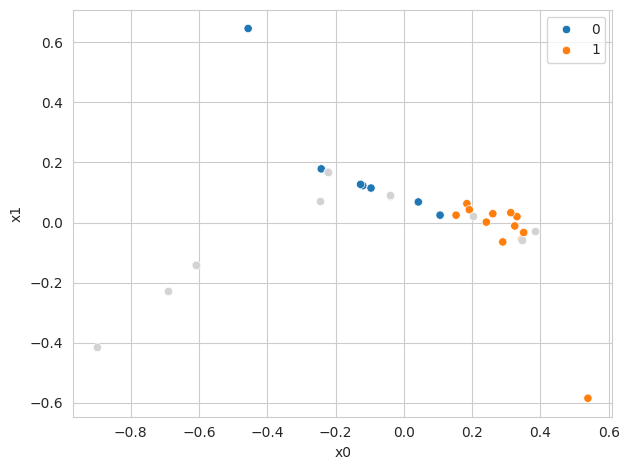

In [15]:
sns.scatterplot(x='x0', y='x1', data=train, hue='group')
sns.scatterplot(x='x0', y='x1', data=test, color='lightgrey')
plt.tight_layout()

We can now use the data in the training set to infer the parameters of a logistic regression model:

In [16]:
logreg = LogisticRegression()
logreg = logreg.fit(train[['x0', 'x1']], train['group'])
print(logreg.coef_)

[[ 1.81282849 -0.62782901]]


We can now use the model to predict the classes using the node features in the test set:

In [17]:
test['predicted'] = logreg.predict(test[['x0', 'x1']])

Let us plot the predictions for the test set along with the fitted decision boundary of the logistic regression classifier.

/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


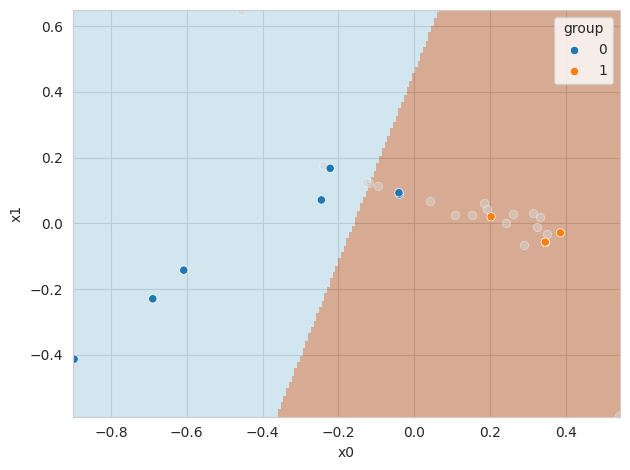

In [18]:
min_x = min(train['x0'].min(), test['x0'].min())
min_y = min(train['x1'].min(), test['x1'].min())

max_x = max(train['x0'].max(), test['x0'].max())
max_y = max(train['x1'].max(), test['x1'].max())

x_mesh, y_mesh = np.meshgrid(np.linspace(min_x, max_x, 200), np.linspace(min_y, max_y, 200))
class_probs = logreg.decision_function(np.c_[x_mesh.ravel(), y_mesh.ravel()])
#print(logits)

#class_probs = torch.softmax(logits, dim=0)
z = np.array(class_probs).reshape(x_mesh.shape)

test['predicted'] = logreg.predict(test[['x0', 'x1']])

fig, ax = plt.subplots()
plt.pcolormesh(x_mesh, y_mesh, z > 0, cmap=plt.cm.Paired, alpha=0.5)
sns.scatterplot(x='x0', y='x1', data=train, color='lightgray', alpha=0.5)
sns.scatterplot(x='x0', y='x1', data=test, hue='group')
plt.tight_layout()

For this (admittedly simple) example, we obtain a relatively high accuracy. We could probably further improve this if we were to use a higher-dimensional embedding (which we did not do here for illustrative purposes).

In [19]:
metrics.balanced_accuracy_score(logreg.predict(test[['x0', 'x1']]), test[['group']])

0.8

## Supervised learning  in networks with non-linear patterns

Above, we have used logistic regression to address supervised node classification. Like other linear classification techniques (e.g. support vector machines without non-linear kernels or a perceptron model), logistic regression gives rise to a linear decision boundary, i.e. it is not expressive enough to address machine learning in many real data sets. Let us motivate this in a synthetic example for a network, where node classification requires non-linear classification techniques. 

We will generate a network based on the circles data set in sklearn:

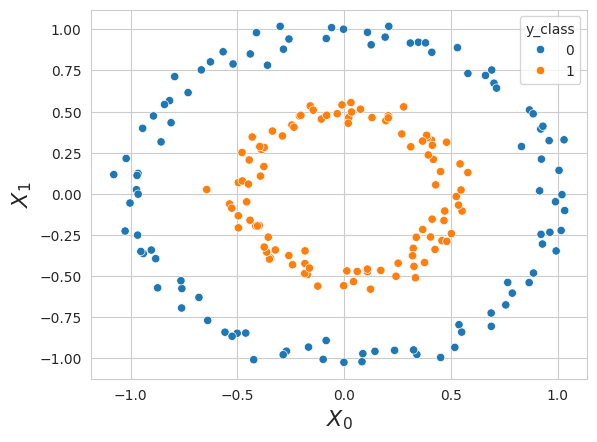

In [20]:
x, c = make_circles(n_samples=200, noise = 0.05, factor = 0.5)
data = pd.DataFrame( {'x0': x[:,0], 'x1': x[:,1], 'y_class': c })

sns.scatterplot(x='x0', y='x1', data=data, hue='y_class')
plt.xlabel(r'$X_0$', fontsize=16)
plt.ylabel(r'$X_1$', fontsize=16);

We now generate links based on a soft rule that builds on the Euclidean distance between the points above, i.e. each node correspond to a point (falling in two different groups according to the colors) and we then add links with a probability that depends on the distance.

In [ ]:
def euclidean_dist(x, y):
    """Computes the Euclidean distance between two points."""
    return np.linalg.norm(x-y)

def soft_rule(dist, **kwargs):
    """Determine probabilistically whether a connection forms based on distance."""
    p = kwargs['beta'] * np.exp(-dist/kwargs['alpha'])
    if np.random.random() <= p:
        return True
    else:
        return False

node_ids = [str(i) for i in range(len(data))]
pos = {str(i): np.array([row['x0'], row['x1']]) for i, row in data.iterrows()}

edges = []
for v in node_ids:
    for w in node_ids:
        if soft_rule(euclidean_dist(pos[v], pos[w]), alpha=0.05, beta=70) and v != w:
            edges.append((v, w))

net = pp.Graph.from_edge_list(edges, mapping=pp.IndexMap(node_ids)).to_undirected()
print(net)

In [ ]:
colors = {}
colors[0] = 'orange'
colors[1] = 'CornflowerBlue'

g_class = {str(i): c[i] for i in range(len(data))}
node_colors = {v: colors[g_class[v]] for v in net.nodes}

pp.plot(net, edge_color='grey', node_color=node_colors);

Let us now create a training-test split of the nodes and assign the features based on a Laplacian embedding:

In [ ]:
nodes = [(v, g_class[v]) for v in net.nodes]
data = pd.DataFrame(nodes, columns=['v', 'group'])

train, test = train_test_split(data, test_size=0.3)
print(train)

In [27]:
def assign_features(embedding, df):
    """Assigns feature columns to a data frame."""
    for index, row in df.iterrows():
        f = embedding[row['v']]
        for i in range(len(f)):
            df.loc[index, 'x{0}'.format(i)] = f[i]        

In [28]:
embedding = laplacian_embedding(net, laplacian(net), d=2)

assign_features(embedding, train)
assign_features(embedding, test)
assign_features(embedding, data)

Let's plot the resulting embedding of the nodes:

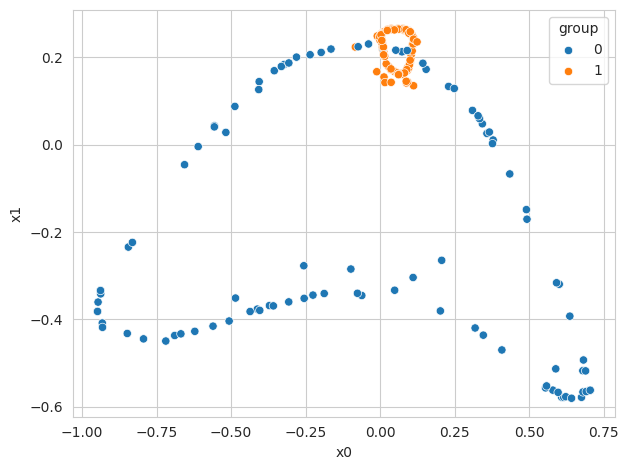

In [29]:
sns.scatterplot(x='x0', y='x1', data=data, hue='group')
plt.tight_layout()

We now apply a logistic regression model:

In [30]:
logreg = LogisticRegression()
logreg = logreg.fit(train[['x0', 'x1']], train['group'].to_numpy())
print(logreg.coef_)

[[0.91077718 4.50570588]]


/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


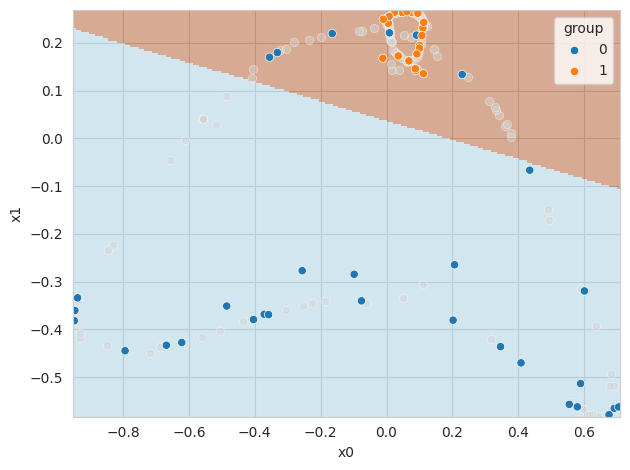

In [31]:
min_x = data['x0'].min()
min_y = data['x1'].min()

max_x = data['x0'].max()
max_y = data['x1'].max()

x_mesh, y_mesh = np.meshgrid(np.linspace(min_x, max_x, 200), np.linspace(min_y, max_y, 200))
class_probs = logreg.decision_function(np.c_[x_mesh.ravel(), y_mesh.ravel()])

z = np.array(class_probs).reshape(x_mesh.shape)

test['predicted'] = logreg.predict(test[['x0', 'x1']])

fig, ax = plt.subplots()
plt.pcolormesh(x_mesh, y_mesh, z > 0, cmap=plt.cm.Paired, alpha=0.5)
sns.scatterplot(x='x0', y='x1', data=train, color='lightgray', alpha=0.5)
sns.scatterplot(x='x0', y='x1', data=test, hue='group')
plt.tight_layout()

Clearly, this simple linear model is not able to capture this non-linear pattern. In the next three notebooks, we will show how we can address this using neural networks.